This is a simple demo in the use of a GNN. There is a minimal dataset and GNN implementation included.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [2]:
import mplhep as mh
mh.style.use("CMS") 

In [4]:
# ===== ME0SegReco Setup =====
import sys
import site

user_site = site.USER_SITE
me0_src = '/eos/home-i01/k/kkeshav/SWAN_projects/me0_v2/ME0SegReco/src'

for path in [user_site, me0_src]:
    if path not in sys.path:
        sys.path.insert(0, path)

from me0.data.datasets.GNNDataset import GNNDataset
from me0.modules.gnn.model import HitGNN
print("✓ ME0SegReco loaded")

✓ ME0SegReco loaded


In [3]:
from me0.data.datasets.GNNDataset import GNNDataset
from me0.modules.gnn.model import HitGNN

ModuleNotFoundError: No module named 'me0'

In [5]:
dataset = GNNDataset("preprocessed_graph", d_strip_max=10, d_ieta_max=2, d_bx_max=1)

Processing...
Done!


In [22]:
# Check GPU availability
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.mps.is_available())
print("Current device:", device)
print("Model device:", next(model.parameters()).device)


CUDA available: True
MPS available: False
Current device: cpu
Model device: cpu


In [23]:
# Note, I changed this to be mps for testing on my laptop, you should use CUDA for any non-mac silicone devices
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device :{device}")
model = HitGNN(input_node_dim=5, edge_dim=5, hidden_dim=10, num_layers=6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(75))
print(f"Model is on:{next(model.parameters()).device}")

Using device :cuda
Model is on:cuda:0


In [24]:
# A quick and dirty function to count the parameters of the model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

total_params = count_parameters(model)
print(f"Total parameters: {total_params}")

Total parameters: 4971


In [25]:
from torch_geometric.loader import DataLoader
from torch.utils.data import Subset

n_train = 10000
n_val = 10000

train_subset =  Subset(dataset, list(range(0, n_train)))
val_subset = Subset(dataset, list(range(n_train, n_train+n_val)))

train_loader = DataLoader(train_subset,  shuffle=True, drop_last=True, batch_size=100)
val_loader = DataLoader(val_subset, shuffle=False, drop_last=True, batch_size=100)


In [26]:
def train_loop(epoch, step, out_df):
    for batch in tqdm(train_loader):
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.float().squeeze())
        loss.backward()
        optimizer.step()
        out_df.loc[len(out_df)] = [epoch, step, loss.item(), None]
        step += 1
    return step

In [27]:
def val_loop(epoch, step, out_df):
    groundtruth = []
    likelihood = []
    with torch.inference_mode():
        loss = 0
        for batch in tqdm(val_loader):
            batch = batch.to(device)
            out = model(batch)
            loss += loss_fn(out, batch.y.float().squeeze()).item()
            # Save predictions
            groundtruth += (batch.y.squeeze()==1).cpu().tolist()
            likelihood += nn.functional.sigmoid(out).cpu().tolist()
        groundtruth = np.array(groundtruth)
        likelihood = np.array(likelihood) 
        out_df.loc[len(out_df)] = [epoch, step, None, loss/len(val_loader)]
        return groundtruth, likelihood

In [28]:
out_df = pd.DataFrame(columns=['epoch', 'step', 'train_loss', 'val_loss'])

num_epoch = 5
step = 0
epoch = 0

groundtruth, likelihood = val_loop(epoch, step, out_df)

for epoch in range(num_epoch+1):
    step = train_loop(epoch, step, out_df)
    groundtruth, likelihood = val_loop(epoch, step, out_df)
    print(f"""
    Epoch {epoch}/{num_epoch}
        train_loss: {out_df[(out_df['epoch'] == epoch)]['train_loss'].dropna().mean()}
        val_loss: {out_df[(out_df['epoch'] == epoch)]['val_loss'].dropna().mean()}
    """) 

100%|██████████| 100/100 [00:01<00:00, 95.66it/s]



    Epoch 0/5
        train_loss: 1.228108484148979
        val_loss: 1.2784646673500537
    


100%|██████████| 100/100 [00:01<00:00, 94.84it/s]



    Epoch 1/5
        train_loss: 0.21699728898704052
        val_loss: 0.10215568147599698
    


100%|██████████| 100/100 [00:01<00:00, 96.26it/s]


...


    Epoch 3/5
        train_loss: 0.06943936247378588
        val_loss: 0.0719842280074954
    


100%|██████████| 100/100 [00:01<00:00, 96.14it/s]



    Epoch 4/5
        train_loss: 0.06156206650659442
        val_loss: 0.06139257011935115
    


100%|██████████| 100/100 [00:01<00:00, 97.19it/s]


    Epoch 5/5
        train_loss: 0.060591450817883016
        val_loss: 0.05560264814645052
    


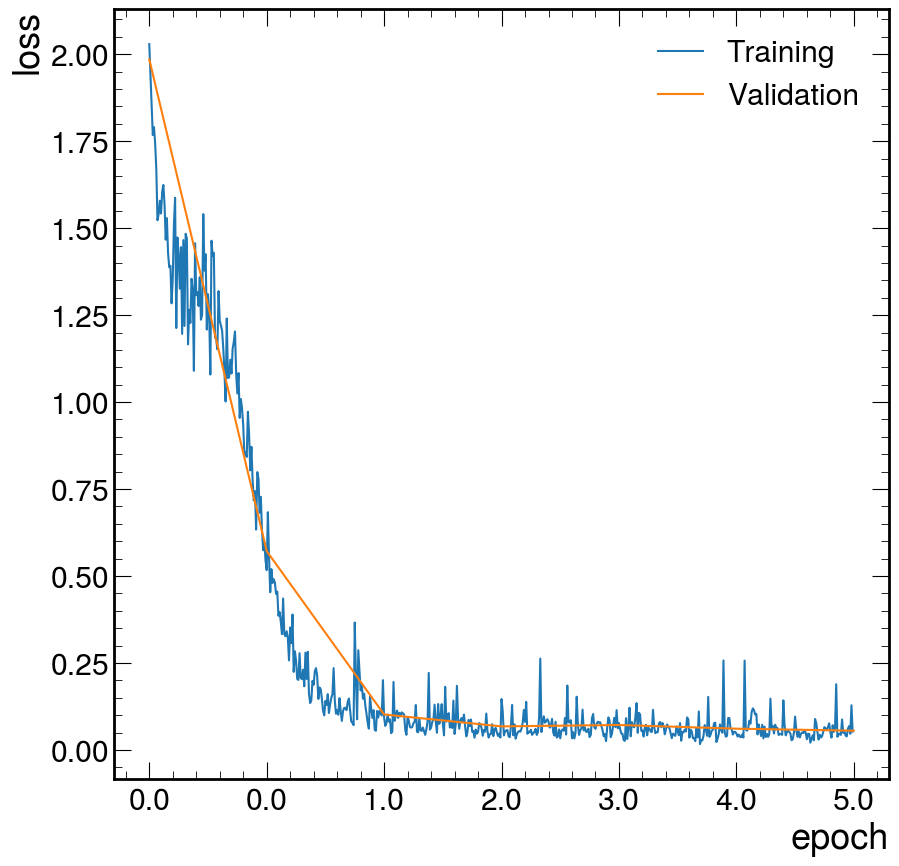

In [29]:

plt.plot(out_df[out_df['train_loss'].notna()]['step'], out_df['train_loss'].dropna(), label='Training')
plt.plot(out_df[out_df['val_loss'].notna()]['step'], out_df['val_loss'].dropna(), label='Validation')
plt.xticks(ticks=out_df[out_df['val_loss'].notna()]['step'], labels=out_df[out_df['val_loss'].notna()]['epoch'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

(0.001, 30.0)

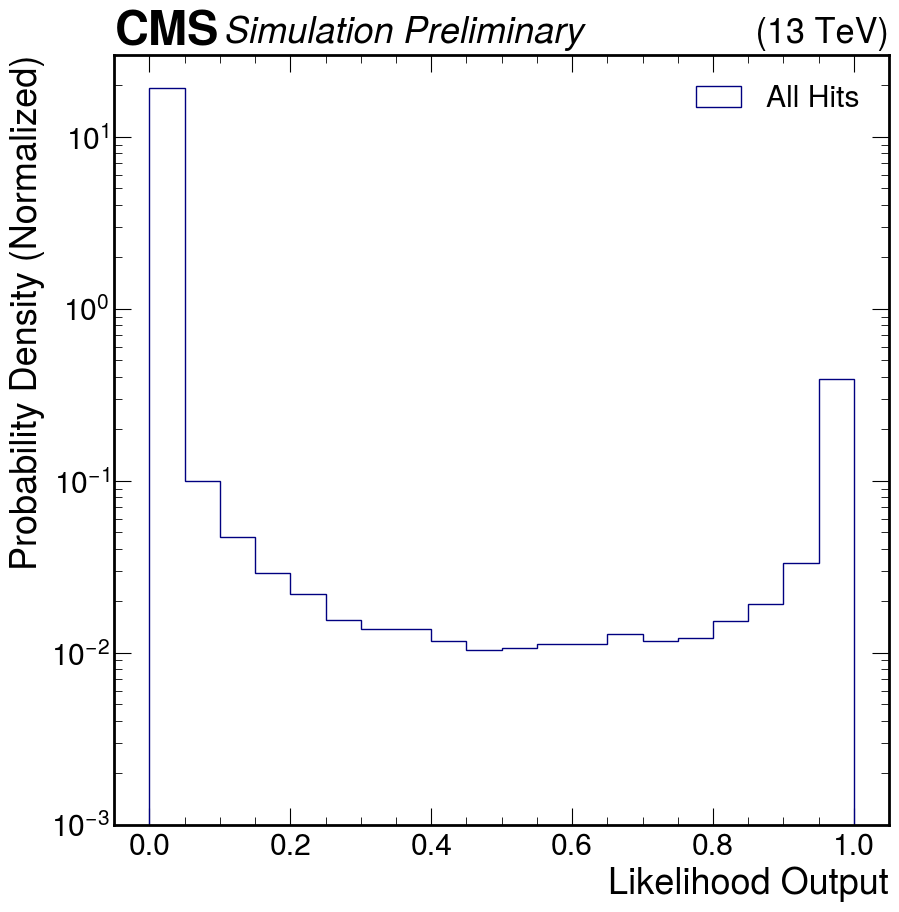

In [30]:
# Now, you have two arrays of data.
# Likelihood contains the model's output probability for each hit
bins = np.linspace(0, 1, 21)
fig, ax = plt.subplots(figsize=(10, 10))
plt.hist(
        likelihood, 
        bins=bins, 
        density=True, 
        label='All Hits',
        histtype='step',
        color='navy'
    )
plt.yscale('log')
plt.legend()
plt.xlabel('Likelihood Output')
plt.ylabel('Probability Density (Normalized)')
mh.cms.label(loc=0, label="Preliminary", data=False) 

plt.ylim(1e-3, 3e1) 



/cvmfs/sft.cern.ch/lcg/views/LCG_108_cuda/x86_64-el9-gcc13-opt/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7129: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


(0.001, 30.0)

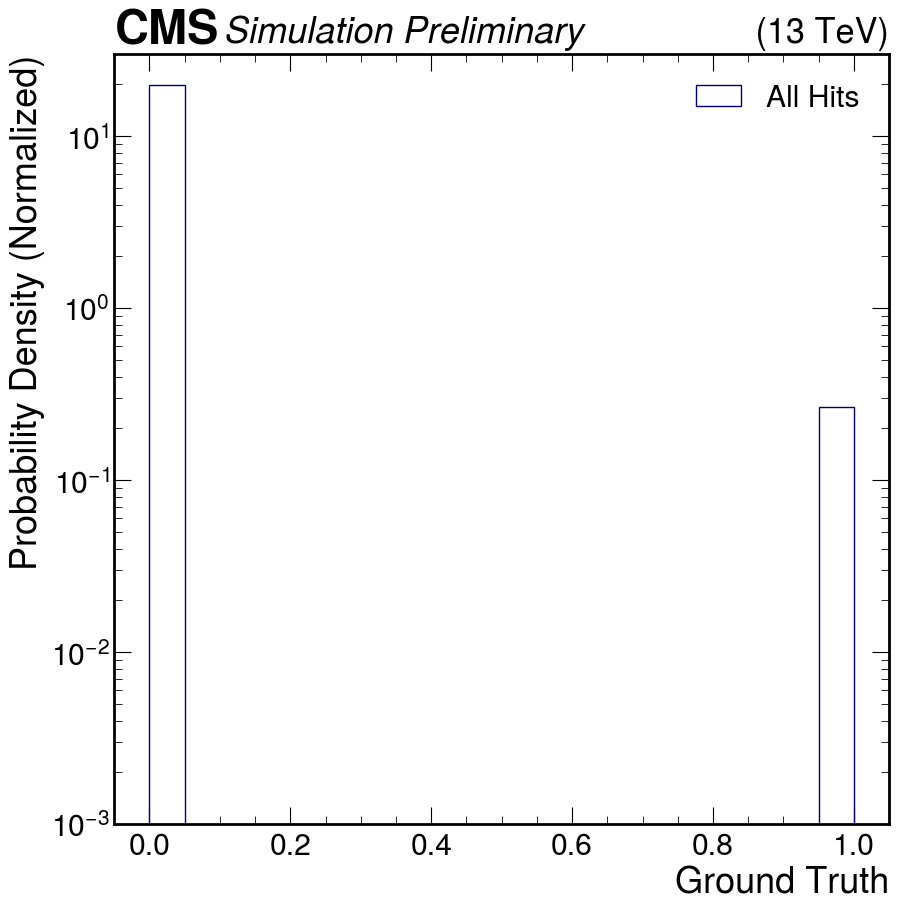

In [31]:
# Groundtruth contains the mc truth of if the hit is a muon or not. 
bins = np.linspace(0, 1, 21)
fig, ax = plt.subplots(figsize=(10, 10))
plt.hist(
        groundtruth, 
        bins=bins, 
        density=True, 
        label='All Hits',
        histtype='step',
        color='navy'
    )
plt.yscale('log')
plt.legend()
plt.xlabel('Ground Truth')
plt.ylabel('Probability Density (Normalized)')
mh.cms.label(loc=0, label="Preliminary", data=False) 

plt.ylim(1e-3, 3e1) 



In [32]:
# And here is a simple bit of code to compute the tpr/fpr for a certain cut value
# 
def compute_tpr_fpr(groundtruth, likelihood, cutoff):
    mask = groundtruth == 1
    n_muons = mask.sum()
    n_non_muons = (1-mask).sum()

    tp = (likelihood[groundtruth] >= cutoff).sum()
    tpr = tp/n_muons

    fp = (likelihood[~groundtruth] >= cutoff).sum()
    fpr = fp / n_non_muons
    return float(tpr), float(fpr)
# Compute the true positive rate and false positve rate for a cutoff of .5 in the likelihood
compute_tpr_fpr(groundtruth, likelihood, .5)

(0.9970164521353678, 0.013078800726972097)

In [33]:
# Compute tpr and fpr for various cutoffs
cutoffs = np.linspace(0, 1, 1000)
tprs = []
fprs = []
for cutoff in cutoffs:
    tpr, fpr = compute_tpr_fpr(groundtruth, likelihood, cutoff)
    tprs.append(tpr)
    fprs.append(fpr)

tprs = np.array(tprs)
fprs = np.array(fprs)

In [34]:
#This function allows you to compute the fpr at a target tpr
def fpr_at_tpr(target_tpr, tprs, fprs, cutoffs):
    # Ensure tprs are sorted increasingly for interpolation
    sort_idx = np.argsort(tprs)
    tprs_sorted = tprs[sort_idx]
    fprs_sorted = fprs[sort_idx]
    cutoffs_sorted = cutoffs[sort_idx]

    # Interpolate FPR and Cutoff
    interpolated_fpr = np.interp(target_tpr, tprs_sorted, fprs_sorted)
    interpolated_cutoff = np.interp(target_tpr, tprs_sorted, cutoffs_sorted)

    return float(interpolated_cutoff), float(interpolated_fpr)

In [35]:
fpr_at_tpr(.9, tprs, fprs, cutoffs), fpr_at_tpr(.95, tprs, fprs, cutoffs), fpr_at_tpr(.995, tprs, fprs, cutoffs)

((0.9906707990041324, 0.002479625335686939),
 (0.9834716295242611, 0.0036632498540574206),
 (0.7793293293293285, 0.009834075777834751))

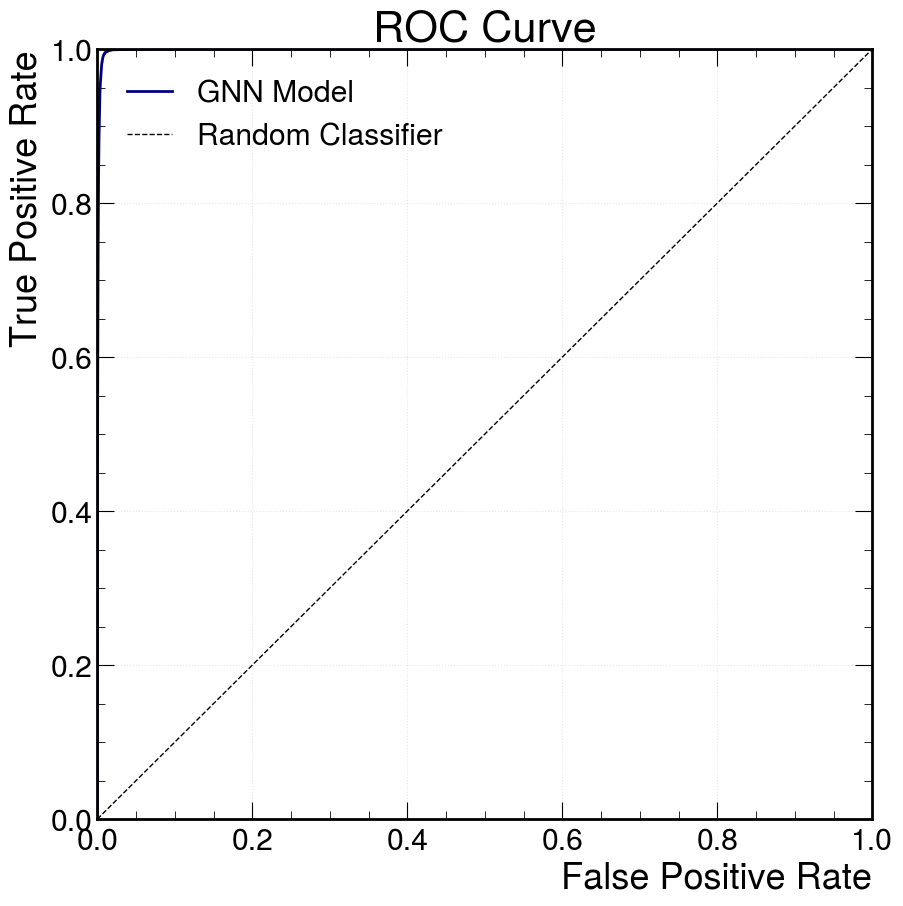

In [41]:
# Plot ROC curve
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(fprs, tprs, linewidth=2, color='navy', label='GNN Model')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
#mh.cms.label(loc=0, label="Preliminary", data=False)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

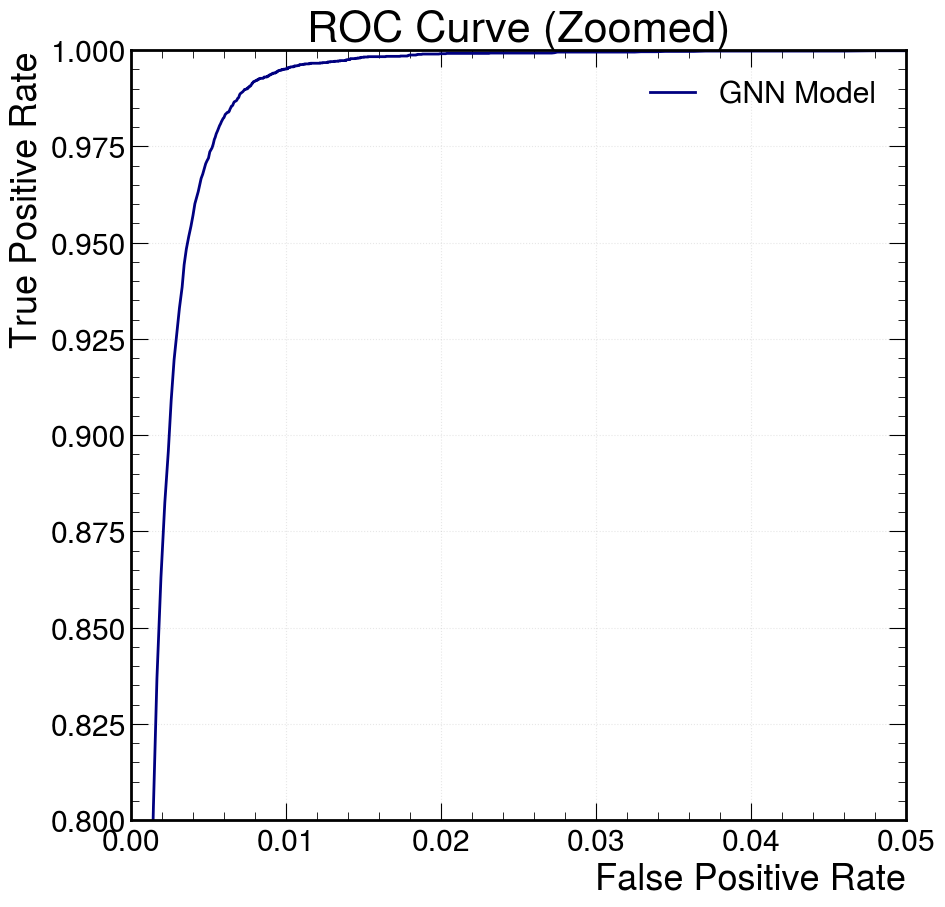

In [42]:
# Zoomed ROC curve (low FPR region)
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(fprs, tprs, linewidth=2, color='navy', label='GNN Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Zoomed)')
plt.legend()
plt.grid(True, alpha=0.3)
#mh.cms.label(loc=0, label="Preliminary", data=False)
plt.xlim(0, 0.05)  # Zoom to low FPR
plt.ylim(0.8, 1.0)  # High TPR region
plt.show()

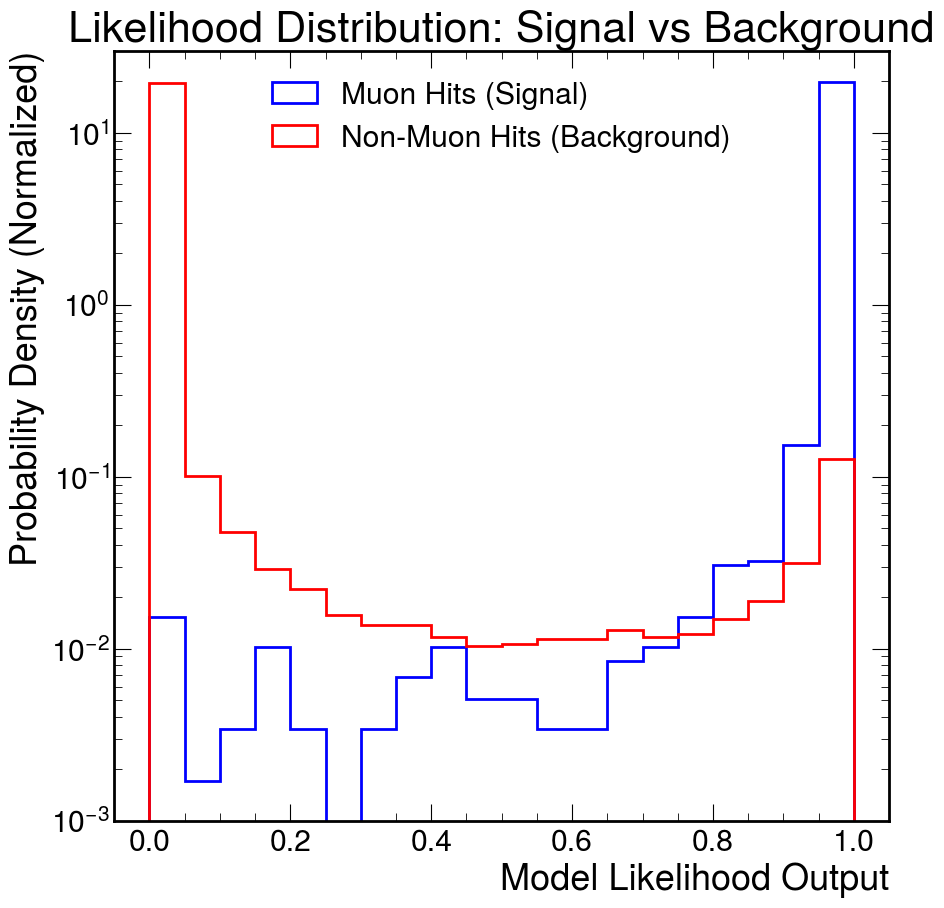

In [43]:
# Compare likelihood for muon hits vs non-muon hits
bins = np.linspace(0, 1, 21)
fig, ax = plt.subplots(figsize=(10, 10))

# Muon hits (signal)
plt.hist(
    likelihood[groundtruth == 1], 
    bins=bins, 
    density=True, 
    label='Muon Hits (Signal)',
    histtype='step',
    color='blue',
    linewidth=2
)

# Non-muon hits (background)
plt.hist(
    likelihood[groundtruth == 0], 
    bins=bins, 
    density=True, 
    label='Non-Muon Hits (Background)',
    histtype='step',
    color='red',
    linewidth=2
)

plt.yscale('log')
plt.legend()
plt.xlabel('Model Likelihood Output')
plt.ylabel('Probability Density (Normalized)')
plt.title('Likelihood Distribution: Signal vs Background')
#mh.cms.label(loc=0, label="Preliminary", data=False)
plt.ylim(1e-3, 3e1)
plt.show()

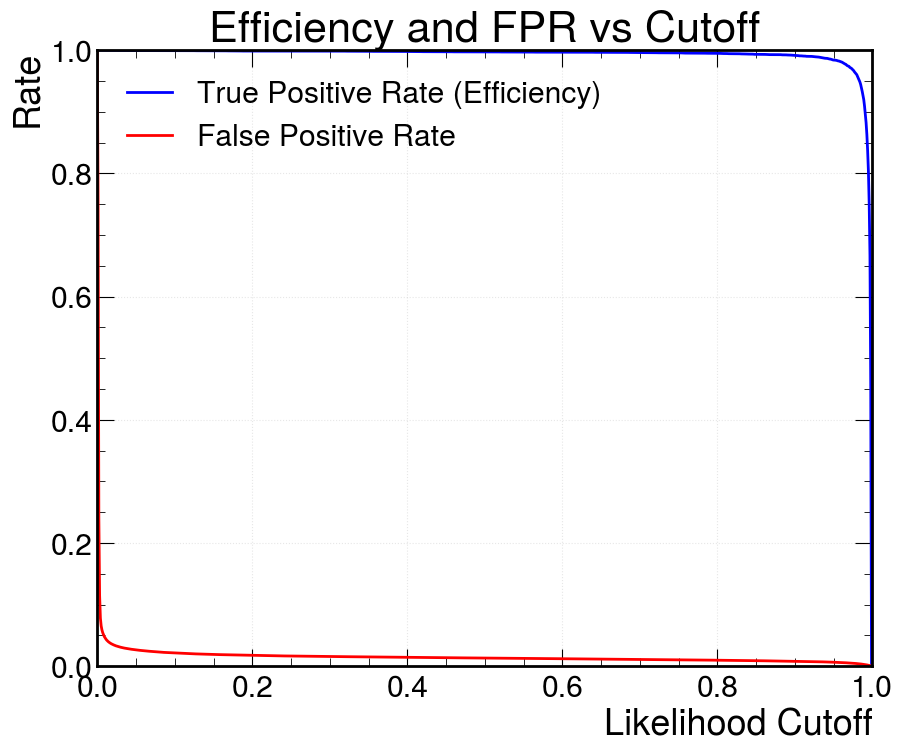

In [44]:
# Plot TPR and FPR vs cutoff value
fig, ax = plt.subplots(figsize=(10, 8))
plt.plot(cutoffs, tprs, label='True Positive Rate (Efficiency)', color='blue', linewidth=2)
plt.plot(cutoffs, fprs, label='False Positive Rate', color='red', linewidth=2)
plt.xlabel('Likelihood Cutoff')
plt.ylabel('Rate')
plt.title('Efficiency and FPR vs Cutoff')
plt.legend()
plt.grid(True, alpha=0.3)
#mh.cms.label(loc=0, label="Preliminary", data=False)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [45]:
# Print some key metrics
print("=== Model Performance Summary ===")
print(f"At 90% TPR: FPR = {fpr_at_tpr(.9, tprs, fprs, cutoffs)[1]:.4f}, Cutoff = {fpr_at_tpr(.9, tprs, fprs, cutoffs)[0]:.4f}")
print(f"At 95% TPR: FPR = {fpr_at_tpr(.95, tprs, fprs, cutoffs)[1]:.4f}, Cutoff = {fpr_at_tpr(.95, tprs, fprs, cutoffs)[0]:.4f}")
print(f"At 99.5% TPR: FPR = {fpr_at_tpr(.995, tprs, fprs, cutoffs)[1]:.4f}, Cutoff = {fpr_at_tpr(.995, tprs, fprs, cutoffs)[0]:.4f}")
print(f"\nTotal muon hits: {(groundtruth == 1).sum()}")
print(f"Total non-muon hits: {(groundtruth == 0).sum()}")
print(f"Signal fraction: {(groundtruth == 1).sum() / len(groundtruth):.4f}")

=== Model Performance Summary ===
At 90% TPR: FPR = 0.0025, Cutoff = 0.9907
At 95% TPR: FPR = 0.0037, Cutoff = 0.9835
At 99.5% TPR: FPR = 0.0098, Cutoff = 0.7793

Total muon hits: 11731
Total non-muon hits: 866058
Signal fraction: 0.0134
